# ✋ Hands-On: Build a Hand Gesture Recogniser

So far, we have seen how Computer Vision can identify important structures in an image using **keypoints and landmarks**.

Now, we will use these hand landmarks to build a system that can recognise different hand gestures.

## 0. Setup

Run the following cells to set up the environment. You do not need to modify the code in this section.

### 0.1 Install dependencies

In [42]:
# !pip install -q mediapipe pandas scikit-learn matplotlib opencv-python

### 0.2 Import Libraries

In [43]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay
)
from pathlib import Path
from urllib.request import urlretrieve

import mediapipe as mp
import mediapipe.tasks as tasks

print("MediaPipe version:", mp.__version__)
print("Setup successful!")

MediaPipe version: 1.0.1
Setup successful!


### 0.3 Download MediaPipe model

This is a pretrained MediaPipe Hand Landmarker model itself.

In [44]:
MODEL_PATH = Path("hand_landmarker.task")

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/"
    "hand_landmarker.task"
)

if not MODEL_PATH.exists():
    print("Downloading MediaPipe Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

print("Model ready:", MODEL_PATH.exists())

Model ready: True


## 1. What Are We Building? ✋

We have seen how Computer Vision can identify important structures in an image using **keypoints and landmarks**.

For our hands-on, we will use these hand landmarks to build a system that can recognise different hand gestures.

Our goal is to answer:

> **Given an unseen image of a hand, can our system recognise the gesture being shown?**

### 1.1 Our Computer Vision Pipeline

Our gesture recognition system will follow this pipeline:

**Hand Image**  
↓  
**MediaPipe Hand Landmarker**  
↓  
**21 Hand Landmarks**  
↓  
**Landmark Features**  
↓  
**Gesture Classifier**  
↓  
**Gesture Prediction**

MediaPipe acts as our **pretrained Computer Vision model**, transforming the raw hand image into a structured representation of the hand.

We will then use this representation to recognise different hand gestures.

### 1.2 Your Task

Some parts of the pipeline have already been prepared so that we can focus on understanding and building the gesture recognition system.

### Provided for you

- Pretrained MediaPipe Hand Landmarker
- Hand landmark extraction setup
- Prepared gesture data
- Visualisation/helper code

### You will

1. 👀 **Explore** how a hand is represented using landmarks
2. 🧩 **Construct features** from the landmark coordinates
3. 🌲 **Train** a gesture classifier
4. 📊 **Evaluate** how well it performs
5. 🖼️ **Test** the complete pipeline on unseen hand images
6. 🔍 **Investigate** where incorrect predictions come from

### 1.3 Gestures We Will Recognise

Our initial system will recognise four gestures:

| Gesture | Label |
|---|---|
| ✋ Open Palm | `OPEN_PALM` |
| ✊ Fist | `FIST` |
| ✌️ Peace | `PEACE` |
| ☝️ Pointing | `POINTING` |

Later, we will test whether our system can recognise these gestures in images it has **not seen before**.

## 2. Explore the Hand Landmark Representation

Before training our gesture recogniser, let's first understand the visual information provided by MediaPipe.

We will start with a hand image and use the pretrained **MediaPipe Hand Landmarker** to extract its 21 landmarks.

### 2.1 Start with a Hand Image

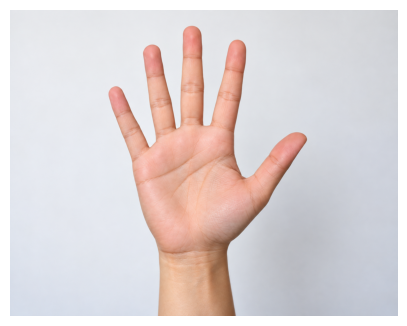

In [45]:
IMAGE_PATH = "../data/workshop images/open_palm.png"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

# OpenCV loads images in BGR format.
# Convert it to RGB for display.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### 2.2 Image -> MediaPipe -> Landmarks

For gesture recognition, we are particularly interested in the **structure of the hand**:

- Where is the wrist?
- Where are the finger joints?
- Where are the fingertips?

MediaPipe Hand Landmarker is a pretrained Computer Vision model that represents a detected hand using **21 landmarks**.

In [46]:
# Configure MediaPipe Hand Landmarker

MODEL_PATH = "hand_landmarker.task"

base_options = tasks.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = tasks.vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

landmarker = tasks.vision.HandLandmarker.create_from_options(
    options
)

In [47]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

result = landmarker.detect(mp_image)

print("Hands detected:", len(result.hand_landmarks))

Hands detected: 1


In [48]:
if result.hand_landmarks:
    hand_landmarks = result.hand_landmarks[0]

    print("Number of landmarks:", len(hand_landmarks))
else:
    raise ValueError("No hand detected in the image.")

Number of landmarks: 21


### 2.3 Visualise the 21 Landmarks

In [49]:
HAND_CONNECTIONS = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),

    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),

    # Middle finger
    (5, 9), (9, 10), (10, 11), (11, 12),

    # Ring finger
    (9, 13), (13, 14), (14, 15), (15, 16),

    # Pinky
    (13, 17), (17, 18), (18, 19), (19, 20),

    # Palm
    (0, 17),
]

In [50]:
def draw_hand_landmarks(image, hand_landmarks):
    output = image.copy()

    height, width, _ = output.shape
    points = []

    # Convert normalized coordinates to pixel coordinates
    for landmark in hand_landmarks:
        x = int(landmark.x * width)
        y = int(landmark.y * height)
        points.append((x, y))

    # Draw connections
    for start, end in HAND_CONNECTIONS:
        cv2.line(
            output,
            points[start],
            points[end],
            (255, 255, 255),
            2
        )

    # Draw landmarks
    for index, point in enumerate(points):
        cv2.circle(
            output,
            point,
            5,
            (0, 255, 0),
            -1
        )

        cv2.putText(
            output,
            str(index),
            (point[0] + 5, point[1] - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (0, 255, 0),
            1
        )

    return output

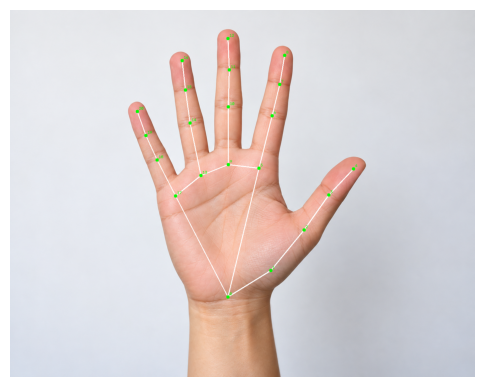

In [51]:
landmark_image = draw_hand_landmarks(
    image_rgb,
    hand_landmarks
)

plt.figure(figsize=(6, 6))
plt.imshow(landmark_image)
plt.axis("off")
plt.show()

### 2.4 What do the landmarks represent?

Each landmark corresponds to a specific part of the hand.

Some useful examples are:

| Landmark | Hand Part |
|---|---|
| `0` | Wrist |
| `4` | Thumb tip |
| `8` | Index fingertip |
| `12` | Middle fingertip |
| `16` | Ring fingertip |
| `20` | Pinky fingertip |

You do **not** need to memorise all 21 landmark numbers!

### 2.5 Inspect the Coordinates

Each landmark contains three normalized coordinates:

- **x** — horizontal position
- **y** — vertical position
- **z** — relative depth

Let's inspect the index fingertip (`landmark 8`).

In [52]:
index_tip = hand_landmarks[8]

print("Index fingertip (Landmark 8)")
print(f"x = {index_tip.x:.3f}")
print(f"y = {index_tip.y:.3f}")
print(f"z = {index_tip.z:.3f}")

Index fingertip (Landmark 8)
x = 0.591
y = 0.126
z = -0.134


### 🔍 Your Turn

Landmark `12` represents the **middle fingertip**.

Can you inspect its `(x, y, z)` coordinates?

In [53]:
# Replace ____ with the correct landmark number

# middle_tip = hand_landmarks[____]
middle_tip = hand_landmarks[12]

print(f"x = {middle_tip.x:.3f}")
print(f"y = {middle_tip.y:.3f}")
print(f"z = {middle_tip.z:.3f}")

x = 0.468
y = 0.080
z = -0.137


### 2.7 What Have We Done?

We started with:

**Raw Image**

and transformed it into:

**21 structured hand landmarks**

Instead of reasoning directly over every pixel in the image, we now have a compact representation describing the **structure and geometry of the hand**.

Next, we will turn these landmarks into features that can be used to recognise different gestures.

## 3. From Landmarks to Gesture Features

We now have **21 landmarks** describing the structure of the hand.

Each landmark contains three coordinates:

- `x`
- `y`
- `z`

This gives us:

**21 landmarks × 3 coordinates = 63 values**

These values can be used to describe the hand's structure and eventually help us distinguish between different gestures.

### 3.1 A Problem With Raw Coordinates

Consider showing the same ✌️ gesture at two different positions in the image.

The gesture has not changed, but the landmark coordinates will be different because the hand has moved.

For example:

**Left side of image** → smaller `x` coordinates  
**Right side of image** → larger `x` coordinates

Should our gesture recogniser consider these to be different gestures?

### 3.2 Look at the raw coordinates

In [54]:
# Let's inspect the first few raw landmark coordinates

for i in range(5):
    landmark = hand_landmarks[i]

    print(
        f"Landmark {i}: "
        f"x={landmark.x:.3f}, "
        f"y={landmark.y:.3f}, "
        f"z={landmark.z:.3f}"
    )

Landmark 0: x=0.469, y=0.783, z=0.000
Landmark 1: x=0.561, y=0.711, z=-0.059
Landmark 2: x=0.632, y=0.600, z=-0.082
Landmark 3: x=0.686, y=0.505, z=-0.100
Landmark 4: x=0.739, y=0.435, z=-0.118


### 3.3 Use the wrist as our reference point

Instead of describing every landmark relative to the entire image,
we can describe each landmark relative to the **wrist**.

MediaPipe uses landmark `0` for the wrist.

For every landmark:

$x_{relative} = x_{landmark} - x_{wrist}$

$y_{relative} = y_{landmark} - y_{wrist}$

$z_{relative} = z_{landmark} - z_{wrist}$

This shifts the hand representation so that the wrist becomes our reference point.

### 💻 Your Turn: Create Wrist-Relative Features

Complete the function below so that every landmark is represented relative to the wrist.

In [55]:
def create_features(hand_landmarks):

    wrist = hand_landmarks[0]
    features = []

    for landmark in hand_landmarks:

        # # TODO: Make each coordinate relative to the wrist
        # relative_x = landmark.x - ________
        # relative_y = landmark.y - ________
        # relative_z = landmark.z - ________

         # SOLUTION
        relative_x = landmark.x - wrist.x
        relative_y = landmark.y - wrist.y
        relative_z = landmark.z - wrist.z

        features.extend([
            relative_x,
            relative_y,
            relative_z
        ])

    return features

💡 **Hint:** `wrist.x`, `wrist.y` and `wrist.z` contain the coordinates of landmark `0`.

### 3.4 Create the feature vector

In [56]:
features = create_features(hand_landmarks)

print("Number of features:", len(features))

print("First 12 features:")
# The first 12 values represent the first 4 landmarks (0, 1, 2, 3),
# with 3 coordinates (x, y, z) for each landmark.

for value in features[:12]:
    print(f"{value:.3f}")

Number of features: 63
First 12 features:
0.000
0.000
0.000
0.092
-0.072
-0.059
0.164
-0.182
-0.082
0.217
-0.277
-0.100


### 3.5 A Quick Check

Since all landmarks are now represented relative to the wrist, what should the wrist's own coordinates become?

Remember:

$x_{relative} = x_{landmark} - x_{wrist}$

For landmark `0`, the landmark itself **is the wrist**.

In [57]:
print("Wrist features:")
print(features[:3])

Wrist features:
[0.0, 0.0, 0.0]


## 4. Meet the Gesture Dataset

So far, we have transformed **one hand image** into 63 landmark features.

To teach a model to recognise gestures, we need many examples of different gestures.

Our dataset was created using the same process:

**Hand Image / Webcam Frame**  
↓  
**MediaPipe Hand Landmarker**  
↓  
**21 Hand Landmarks**  
↓  
**Wrist-Relative Coordinates**  
↓  
**63 Features + Gesture Label**

### 4.1 What Does One Row Represent?

Each row in our dataset represents **one detected hand at one point in time**.

For each hand, we have:

- **63 landmark features** — 21 landmarks × `(x, y, z)`
- **Gesture label** — the gesture being shown
- **Handedness** — left or right hand
- **Member** — which contributor the sample came from
- **Session** — the data collection session

The landmark coordinates have already been transformed relative to the wrist, as we explored in the previous section.

| Landmark Features | Label | Handedness | Member | Session |
|---|---|---|---|---|
| `x0, y0, z0, ... x20, y20, z20` | `PEACE` | `RIGHT` | `A` | `1` |

### 4.2 Load the Collected Data

In [58]:
member_a = pd.read_csv("../data/member_a_gestures.csv")
# member_b = pd.read_csv("../data/member_b_gestures.csv")
# member_c = pd.read_csv("../data/member_c_gestures.csv")

In [59]:
print("Member A:", member_a.shape)
# print("Member B:", member_b.shape)
# print("Member C:", member_c.shape)

Member A: (160, 67)


### 4.3 Take a Look at the Data

In [60]:
member_a[
    [
        "x0", "y0", "z0",
        "x8", "y8", "z8",
        "label",
        "handedness",
        "member"
    ]
].head()

,x0,y0,z0,x8,y8,z8,label,handedness,member
0,0.0,0.0,0.0,0.162788,-0.450639,-0.081764,OPEN_PALM,RIGHT,A
1,0.0,0.0,0.0,0.162451,-0.452061,-0.080887,OPEN_PALM,RIGHT,A
2,0.0,0.0,0.0,0.159847,-0.452839,-0.081503,OPEN_PALM,RIGHT,A
3,0.0,0.0,0.0,0.066231,-0.514734,-0.086074,OPEN_PALM,RIGHT,A
4,0.0,0.0,0.0,0.022018,-0.522402,-0.099823,OPEN_PALM,RIGHT,A


### 4.4 What gestures are in our dataset?

In [61]:
member_a["label"].value_counts()

label
OPEN_PALM    40
FIST         40
PEACE        40
POINTING     40
Name: count, dtype: int64

### 4.5 Why did we collect data from different people?


A gesture recogniser should not only work for the people whose hands it saw during training.

We therefore collected data from three different contributors.

For our experiment:

**Members A + B → Training data**

**Member C → Held-out test data**

Member C's hand-landmark samples will **not be shown to the classifier during training**.

Later, we will use Member C to ask:

> **Can our system recognise gestures from a person it has never seen before?**

### 4.6 Combine A + B into our training dataset

In [62]:
# train_data = pd.concat(
#     [member_a, member_b],
#     ignore_index=True
# )

# test_data = member_c.copy()


train_data = pd.concat(
    [member_a, member_a],
    ignore_index=True
)

test_data = member_a.copy()

print("Training samples:", len(train_data))
print("Held-out test samples:", len(test_data))

Training samples: 320
Held-out test samples: 160


### 4.7 What Will Our Classifier Actually See?

Not every column should be given to the classifier.

#### Features

The classifier receives only the **63 landmark coordinates**:

`x0, y0, z0, ... x20, y20, z20`

#### Target

The classifier tries to predict:

`label`

#### Metadata

These columns help us understand and evaluate the dataset, but should **not** be used as model features:

- `member`
- `handedness`
- `session`

For example, giving the model `member = A` would allow it to learn information about who produced the sample rather than focusing only on hand geometry.

### 4.8 What is going on right now?

We have transformed visual hand data into a structured dataset:

**Hand Images / Webcam Frames**  
↓  
**MediaPipe Hand Landmarks**  
↓  
**Wrist-Relative Landmark Features**  
↓  
**Labelled Gesture Dataset**

And we have deliberately separated our contributors:

**Members A + B → Training**

**Member C → Unseen-person testing**

Next, we will use the landmark representation to train our gesture recogniser.

## 5. Train the Gesture Classifier

We now have:

- **Members A + B** → Training data
- **Member C** → Held-out test data

Our goal is to learn the relationship between the **hand landmark representation** and the gesture being shown.

We will use a **Random Forest classifier** as a simple baseline.

> Our focus is not the Random Forest algorithm itself, but how the visual features extracted from our Computer Vision pipeline can be used to recognise gestures.

### 5.1 Separate Features and Labels

In [63]:
feature_columns = [
    coordinate
    for i in range(21)
    for coordinate in (f"x{i}", f"y{i}", f"z{i}")
]

X_train = train_data[feature_columns]
y_train = train_data["label"]

X_test = test_data[feature_columns]
y_test = test_data["label"]

print(f"Training samples: {len(X_train)}")
print(f"Held-out test samples: {len(X_test)}")

Training samples: 320
Held-out test samples: 160


### 🤔 Think About It

Why are we keeping **all of Member C's samples** out of the training data?

Instead of asking:

> "Can the model recognise another frame similar to one it has already seen?"

we are asking a harder and more realistic question:

> **"Can the model recognise gestures from a person whose hand it has never seen before?"**

### 5.2 Create the Classifier and Model Training

We will use a **Random Forest classifier** as our baseline model.

Random Forest combines predictions from multiple decision trees to make a final classification.

Since we have already covered Machine Learning previously, we will focus on how the classifier fits into our overall Computer Vision pipeline.

In [64]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [65]:
# 💻 YOUR TURN
# Train the model using Members A + B

# model.______(X_train, y_train)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [66]:
# let's evaluate the model on the held-out test set (Member C)

predictions = model.predict(X_test)

print("Number of predictions:", len(predictions))

Number of predictions: 160


In [67]:
# Evaluate the model

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.head(10)

,Actual,Predicted
0,OPEN_PALM,OPEN_PALM
1,OPEN_PALM,OPEN_PALM
2,OPEN_PALM,OPEN_PALM
3,OPEN_PALM,OPEN_PALM
4,OPEN_PALM,OPEN_PALM
5,OPEN_PALM,OPEN_PALM
6,OPEN_PALM,OPEN_PALM
7,OPEN_PALM,OPEN_PALM
8,OPEN_PALM,OPEN_PALM
9,OPEN_PALM,OPEN_PALM


## 6. Evaluate the Gesture Classifier

In [68]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Held-out participant accuracy: {accuracy:.1%}")

Held-out participant accuracy: 100.0%


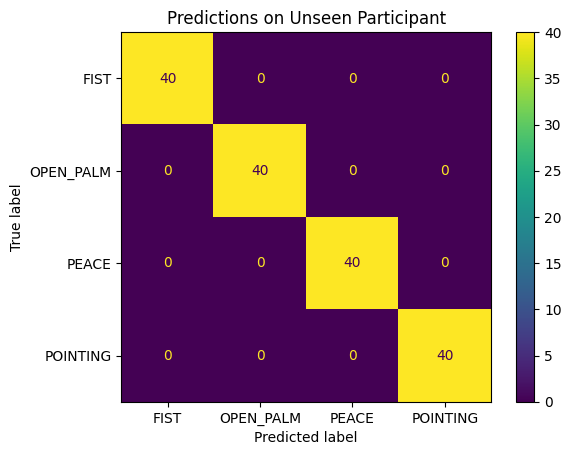

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Predictions on Unseen Participant")
plt.show()

Which gestures generalised well? Which were confused?

## 7. Test the Full CV Pipeline

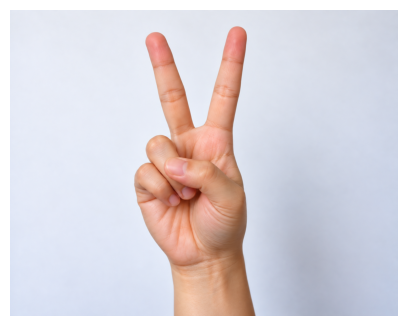

In [71]:
UNSEEN_IMAGE_PATH = "../data/workshop images/peace.png"

unseen_image = cv2.imread(UNSEEN_IMAGE_PATH)
unseen_image_rgb = cv2.cvtColor(
    unseen_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5, 5))
plt.imshow(unseen_image_rgb)
plt.axis("off")
plt.show()

In [72]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=unseen_image_rgb
)

result = landmarker.detect(mp_image)

unseen_landmarks = result.hand_landmarks[0]

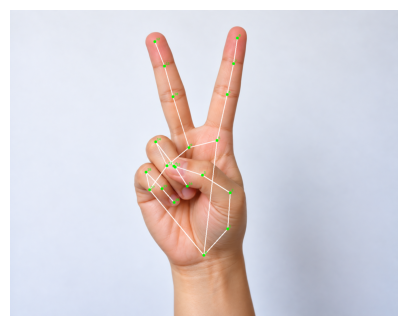

In [73]:
landmark_image = draw_hand_landmarks(
    unseen_image_rgb,
    unseen_landmarks
)

plt.figure(figsize=(5, 5))
plt.imshow(landmark_image)
plt.axis("off")
plt.show()

Convert the landmarks into the SAME features.

In [74]:
unseen_features = create_features(
    unseen_landmarks
)

print("Number of features:", len(unseen_features))

Number of features: 63


In [75]:
X_unseen = pd.DataFrame(
    [unseen_features],
    columns=feature_columns
)

We start predict!

In [76]:
prediction = model.predict(X_unseen)[0]

print("Predicted gesture:", prediction)

Predicted gesture: PEACE


In [77]:
probabilities = model.predict_proba(X_unseen)[0]

for label, probability in zip(
    model.classes_,
    probabilities
):
    print(f"{label:12s}: {probability:.1%}")

FIST        : 3.0%
OPEN_PALM   : 7.0%
PEACE       : 88.0%
POINTING    : 2.0%


# YAYYYYYYYYYYYYY 

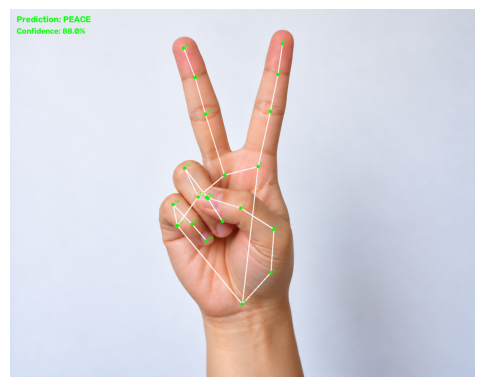

In [78]:
# Draw the detected landmarks
prediction_image = draw_hand_landmarks(
    unseen_image_rgb,
    unseen_landmarks
)

# Find the probability of the predicted class
predicted_index = list(model.classes_).index(prediction)
confidence = probabilities[predicted_index]

# Add prediction text to the image
cv2.putText(
    prediction_image,
    f"Prediction: {prediction}",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 255, 0),
    2
)

cv2.putText(
    prediction_image,
    f"Confidence: {confidence:.1%}",
    (20, 75),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 0),
    2
)

# Display final result
plt.figure(figsize=(6, 6))
plt.imshow(prediction_image)
plt.axis("off")
plt.show()

Feel free to try your own hand gesture picture as well!